In [1]:
import keras
import datetime
import tensorflow                       as tf
from tensorflow.keras.callbacks         import TensorBoard
from tensorflow.keras.layers            import Input, Lambda,UpSampling2D, Conv2D,Dropout,MaxPooling2D,Conv2DTranspose,concatenate,BatchNormalization, Activation
from tensorflow.keras.models            import Model
from tensorflow.keras.optimizers        import Adam,RMSprop,SGD
from keras.utils                        import plot_model
from tensorflow.keras                   import layers, models
from tensorflow.keras.losses            import mae
import sys
import os
import numpy as np
import math
import random, time
from pathlib                        import Path
from PIL                            import Image

import skimage                      as ski
from   skimage.filters              import threshold_otsu
from   skimage                      import io, color
from   skimage.color                import rgb2gray
from   skimage                      import filters
import cv2                          as cv
import matplotlib.pyplot            as plt 
import gc
import glob
from skimage                        import img_as_ubyte
from skimage                        import io
import shutil
import pandas as pd
tf.keras.backend.clear_session()

2025-06-04 17:34:43.481678: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749072883.542319   14800 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749072883.559939   14800 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749072883.726219   14800 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749072883.726274   14800 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749072883.726280   14800 computation_placer.cc:177] computation placer alr

In [2]:
#directory = '/home/guiomar/Desktop/CODES/predicting-flow-patterns'
directory = '/home/ppgi/Trabajo/predicting-flow-patterns'

d1=directory+'/G_Masked'
d2=directory+'/P_Masked'
d3=directory+'/V_Masked'
d4=directory+'/Vx_Masked'
d5=directory+'/Vy_Masked'

gtrain= d1+'/train'
gtest=d1+'/test'
gval=d1+'/valid'

ptrain=d2+'/train'
ptest=d2+'/test'
pval=d2+'/valid'

vtrain=d3+'/train'
vtest=d3+'/test'
vval=d3+'/valid'

vxtrain=d4+'/train'
vxtest=d4+'/test'
vxval=d4+'/valid'

vytrain=d5+'/train'
vytest=d5+'/test'
vyval=d5+'/valid'

In [3]:
nbatch = 10

In [4]:
def dataset_array(g_path,p_path,v_path,vx_path,vy_path):
    """
    Loads and preprocesses a single set of data files.
    This function is designed to be used with tf.data.Dataset.map().
    """
    def load_array(geo,p,v,vx,vy):
        '''
        Inner function executed by tf.numpy_function.
        It loads numpy arrays from the provided file paths
        '''
        pre = np.load(p)   
        vel = np.load(v)
        velx = np.load(vx)
        vely = np.load(vy)
        g = np.load(geo)
        y = np.concatenate([pre, vel, velx, vely], axis=-1)
        return g,y
    
    x,y= tf.numpy_function(load_array,[g_path,p_path,v_path, vx_path,vy_path], [tf.float64,tf.float64])

    y.set_shape([y.shape[0],y.shape[1],y.shape[2]])
    x.set_shape([x.shape[0],x.shape[1],x.shape[2]])
  
    return x,y 


def create_dataset(p_path,v_path, vx_path,vy_path,g_path,batch_size = nbatch):
    p_files = sorted(glob.glob(os.path.join(p_path, "*.npy")))
    v_files = sorted(glob.glob(os.path.join(v_path, "*.npy")))
    vx_files = sorted(glob.glob(os.path.join(vx_path, "*.npy")))
    vy_files = sorted(glob.glob(os.path.join(vy_path, "*.npy")))
    g_files = sorted(glob.glob(os.path.join(g_path, "*.npy")))

    dataset = tf.data.Dataset.from_tensor_slices((p_files,v_files,vx_files,vy_files,g_files))
    dataset = dataset.map(dataset_array, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    return dataset

train_ds =create_dataset(gtrain,ptrain,vtrain,vxtrain,vytrain)
test_ds  =create_dataset(gtest,ptest,vtest,vxtest,vytest)
valid_ds =create_dataset(gval,pval,vval,vxval,vyval)


I0000 00:00:1749072888.345297   14800 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1885 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


In [5]:
num_epochs    =50
patience      =10     # How long to wait after last time validation loss improved
LR            =0.0001

# Model name
model_name    ="U-Net"
#save_in      ='/home/guiomar/Desktop/CODES/predicting-flow-patterns'
save_in       ='/home/ppgi/Trabajo/predicting-flow-patterns'

# image dimensions
img_width     =  256   # 739   G:737
img_height    =  64   # 185
channel       =  1

#number_of_filters = [64, 128, 256, 512, 1024]
number_of_filters = [32,64,128,256,512]

type_padding = 'same'
f_activation = 'relu'
f_activation_last='relu'
#optimizer = RMSprop(learning_rate=LR)
optimizer = Adam(learning_rate=LR)
#optimizer = SGD(learning_rate=LR, momentum=0.9)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',  min_delta=1e-2, patience=patience, restore_best_weights=True,verbose=1)
save = save_in + '/Results_weights/Best_weights.weights.h5'
checkpoint_cb=tf.keras.callbacks.ModelCheckpoint(save,save_weights_only=True)


In [6]:
def conv_block_batchnorm(filters,x):
    conv = Conv2D(filters, (3, 3), padding=type_padding)(x)
    conv= BatchNormalization()(conv)
    conv = Activation(f_activation)(conv)
    conv = Conv2D(filters, (3, 3), padding=type_padding)(conv)
    conv= BatchNormalization()(conv)
    conv = Activation(f_activation)(conv)
    return conv
    
def conv_block(filters,x):
    conv = Conv2D(filters, (3, 3), activation=f_activation, padding=type_padding)(x)
    conv = Conv2D(filters, (3, 3), activation=f_activation, padding=type_padding)(conv)
    return conv    

def encoder(x,filters):
    conv = conv_block_batchnorm(filters,x)
    downsample = MaxPooling2D((2,2))(conv)
    return conv,downsample

def biLSTM(x,units=128):
    _, h, w, c = x.shape #Flatten spatial dimensions for LSTM
    x_reshaped = layers.Reshape((h*w, c))(x)
    x_bilstm = layers.Bidirectional(layers.LSTM(units, return_sequences=True))(x_reshaped) 
    x_bilstm = layers.Reshape((h, w, units*2))(x_bilstm)
    return x_bilstm

def decoder(x1,x2,filters,transpose=None):
    if transpose != None:
        conv_up = Conv2DTranspose(filters,(2,2),strides=(2, 2),padding=type_padding)(x1)
    else:
        conv_up = UpSampling2D((2, 2))(x1)
   
    concat=concatenate([conv_up,x2],axis = 3)
    up = conv_block(filters, concat)
    return up

In [7]:
# number_of_filters = [32,64,128,256,512]
def make_model():
    
    image_input = Input((img_height, img_width, channel))
    
    conv1,down_block1 = encoder (image_input, number_of_filters[0])
    conv2,down_block2 = encoder (down_block1 , number_of_filters[1])
    conv3,down_block3 = encoder (down_block2 , number_of_filters[2])
    conv4,down_block4 = encoder (down_block3 , number_of_filters[3])

    conv5 = conv_block(number_of_filters[4],down_block4)
   
 
    up6=decoder(conv5,conv4,number_of_filters[3],transpose='yes')
    up7=decoder(up6,conv3,number_of_filters[2],transpose='yes')
    up8=decoder(up7,conv2,number_of_filters[1],transpose='yes')
    up9=decoder(up8,conv1,number_of_filters[0],transpose='yes')

    flows_out = Conv2D(4, (1, 1), activation=f_activation_last,name='flows_output',padding="same")(up9)

    # construct model
    model =  keras.Model(inputs=image_input, outputs=[flows_out],name= model_name)
    
    model.summary()

    model.compile(optimizer=optimizer, 
              loss = 'mean_squared_error',
              
              metrics= ['mae'] )

    return model  

In [8]:
M=make_model()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 256,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 256,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 256,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 256,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 256,   │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 256,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 256,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 128,   │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 128,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 128,   │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 64,    │        512 │ conv2d_4[0][0]  

 Total params: 7,763,460 (29.62 MB)

 Trainable params: 7,761,540 (29.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [9]:
print("Starting trainig")

history = M.fit(train_ds,epochs=num_epochs,validation_data = valid_ds,callbacks=[early_stopping,checkpoint_cb])
callbacks = [tf.keras.callbacks.ModelCheckpoint("Unet.keras",save_best_only=True)]
M.save('Completed_Model_fourdecoders.h5')

Starting trainig
Epoch 1/50


I0000 00:00:1749072894.265544   14846 service.cc:152] XLA service 0x7f42000032d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749072894.265558   14846 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-06-04 17:34:54.463982: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749072895.387591   14846 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-06-04 17:34:58.005632: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.57 = (f32[10,32,64,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[10,1,64,256]{3,2,1,0} %bitcast.12565, f32[32,1,3,3]{3,2,1,0} %bitcast.11628, f32[32]{0} %bitcast.13973), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_targe

  1/140 ━━━━━━━━━━━━━━━━━━━━ 53:44 23s/step - loss: 0.0840 - mae: 0.2185

I0000 00:00:1749072912.500392   14846 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0258 - mae: 0.1076

2025-06-04 17:35:27.588333: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.65 = (f32[10,512,4,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[10,256,4,16]{3,2,1,0} %bitcast.1588, f32[512,256,3,3]{3,2,1,0} %bitcast.1595, f32[512]{0} %bitcast.1597), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="U-Net_1/conv2d_8_1/convolution" source_file="/home/ppgi/miniconda3/envs/newEnviroment/lib/python3.9/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-06-04 17:35:27.818723: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc

140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 136ms/step - loss: 0.0257 - mae: 0.1074 - val_loss: 0.0215 - val_mae: 0.1126
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 112ms/step - loss: 0.0033 - mae: 0.0328 - val_loss: 0.0201 - val_mae: 0.1136
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - loss: 0.0021 - mae: 0.0225 - val_loss: 0.0122 - val_mae: 0.0882
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0015 - mae: 0.0168 - val_loss: 0.0031 - val_mae: 0.0390
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0013 - mae: 0.0141 - val_loss: 0.0017 - val_mae: 0.0239
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - loss: 0.0011 - mae: 0.0125 - val_loss: 0.0019 - val_mae: 0.0314
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 8.5258e-04 - mae: 0.0110 - val_loss: 0.0018 - val_mae: 0.0304
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 8.0906e-04 - mae: 0.0102 - val_loss: 0.0015 - val_mae: 0.0271
Epoch 9/50
140/140 ━━━━━━━━━━━━━━━━

In [10]:
results = M.evaluate(test_ds) 
print("Evaluation results:")
for name, value in zip(M.metrics_names, results):
    print(f"{name}: {value:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0031 - mae: 0.0390
Evaluation results:
loss: 0.0030
compile_metrics: 0.0389


In [11]:
xtrue=[]
ytrue=[]
for x,y in test_ds:
    xtrue.append(x.numpy())
    ytrue.append(y.numpy())
ypred = list()    
for i in range(len(ytrue)):    
    ypred.append(M.predict(xtrue[i]))

2025-06-04 17:38:44.683640: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 827ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━

In [12]:
def plotting():
    N = random.randint(0, len(xtrue)-1)
    M = random.randint(0, nbatch-1)
    titles = [ 'P pred', 'P true','V pred', 'V true','Vx pred', 'Vx true','Vy pred', 'Vy true']
    fig, axes = plt.subplots(4, 3, figsize=(16, 10))
    
    error=[]
    for i in range(4):
            error.append(np.abs(ytrue[M][N][:,:,i]- ypred[M][N][:,:,i]))

            axes[i,0].imshow(ypred[M][N][:,:,i], cmap='gray')
            axes[i, 0].set_title(titles[2*i])
            axes[i, 0].axis('off')

            axes[i,1].imshow(ytrue[M][N][:,:,i], cmap='gray')
            axes[i, 1].set_title(titles[2*i+1])
            axes[i, 1].axis('off')

            e=axes[i,2].imshow(error[0], cmap='turbo')
            axes[i, 2].set_title('Absolute Error')
            axes[i, 2].axis('off')
            plt.colorbar(e, ax=axes[i,2], fraction=0.046)

    for ax in axes.flat:
        ax.axis('off')

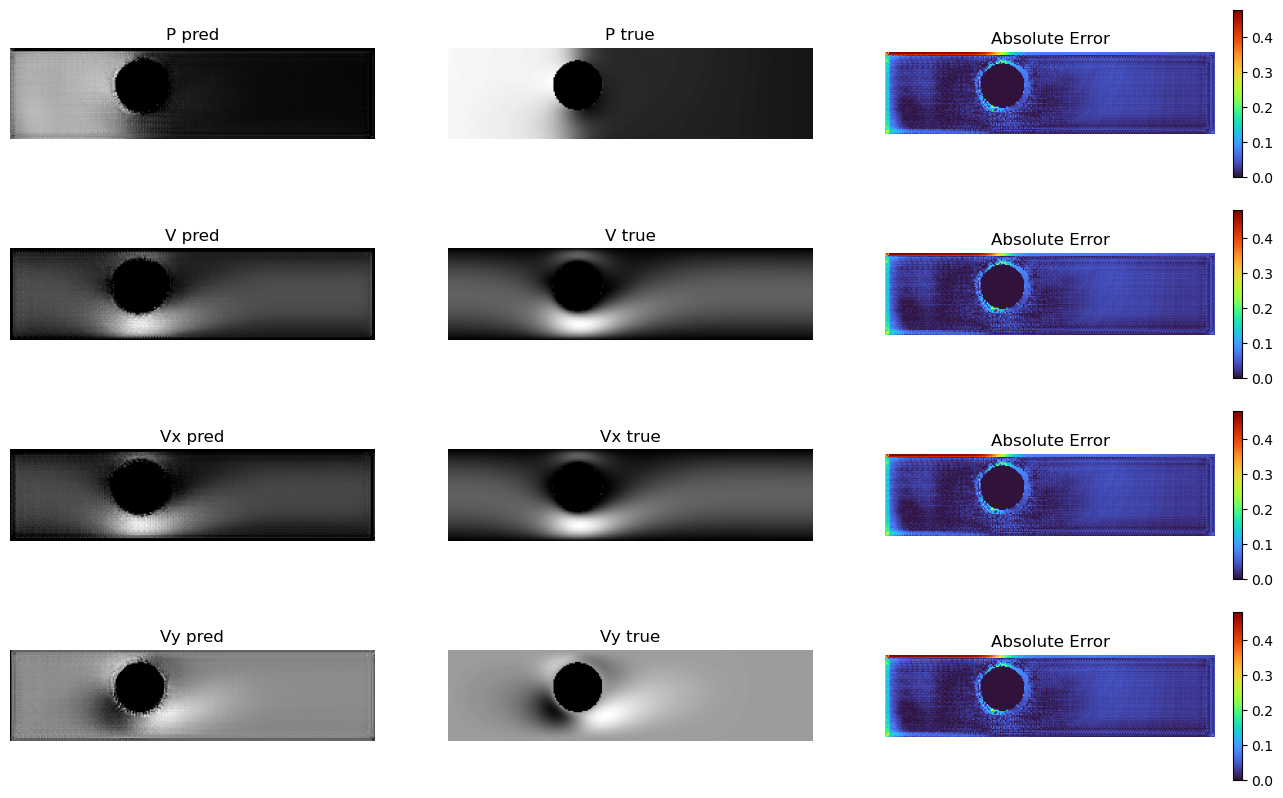

In [19]:
plotting()

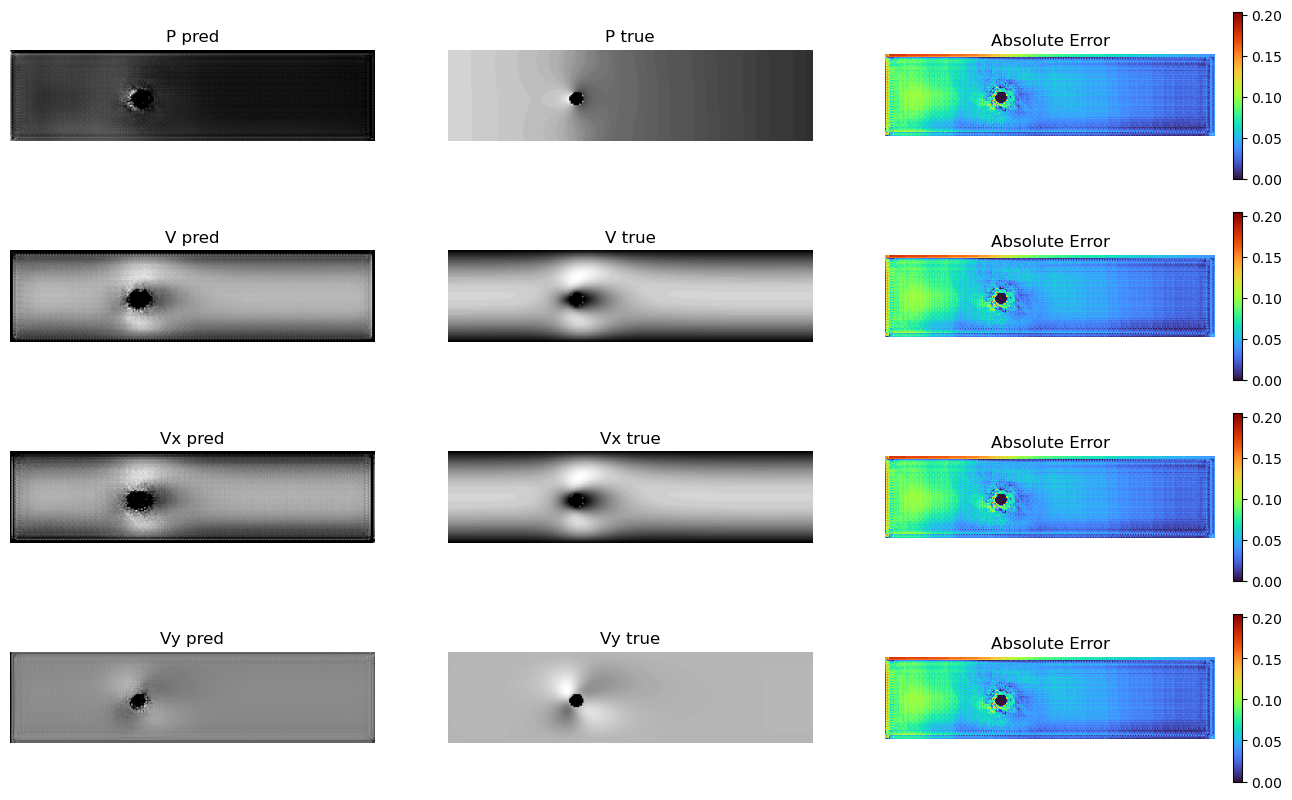

In [27]:
plotting()

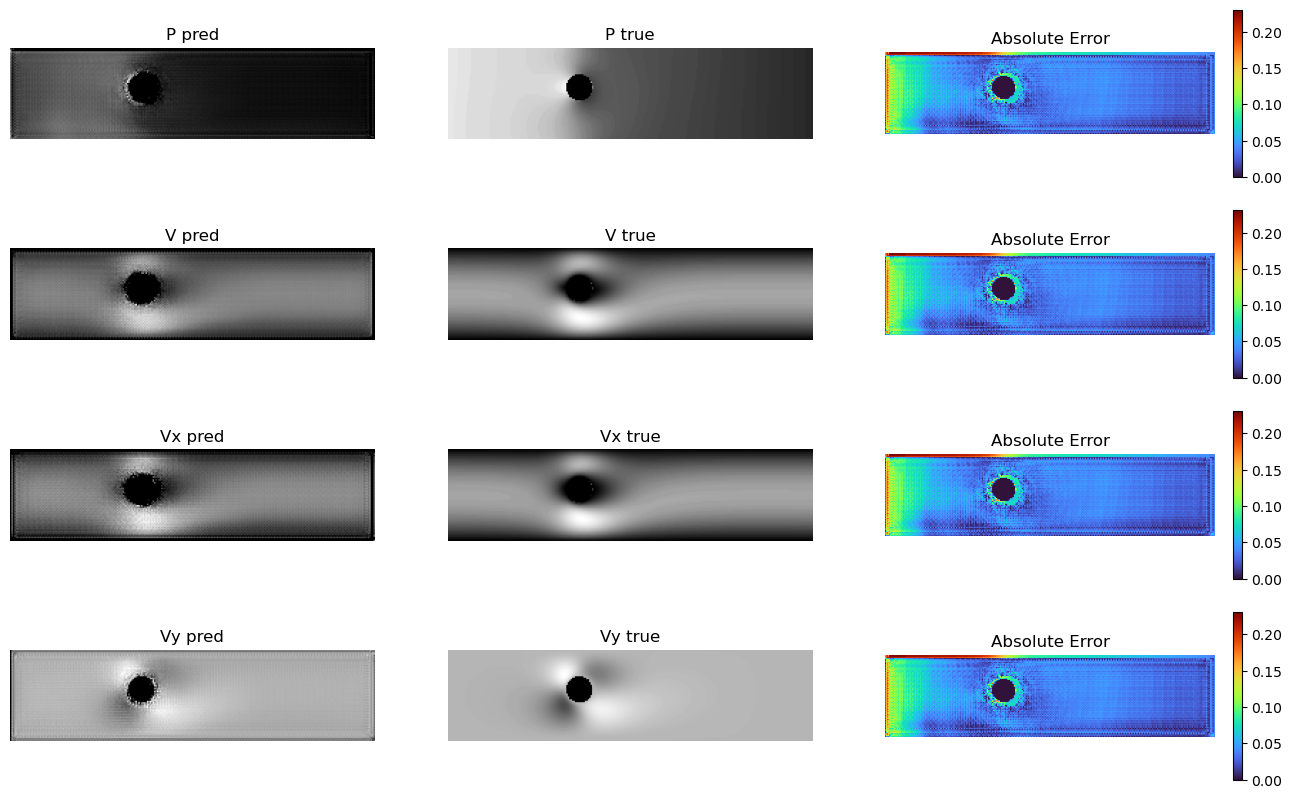

In [31]:
plotting()

In [33]:
# Recolectar predicciones
y_preds = []
y_trues = []

for x_batch, y_batch in test_ds:
    y_pred = M.predict(x_batch)
    y_preds.append(y_pred)
    y_trues.append(y_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━

In [34]:
y_preds = np.concatenate(y_preds, axis=0)  # (N, H, W, 4)
y_trues = np.concatenate(y_trues, axis=0)

In [36]:
# Calcular MSE y MAE por canal
from sklearn.metrics import mean_squared_error, mean_absolute_error
for i, var in enumerate(["p", "v", "vx", "vy"]):
    mse = mean_squared_error(y_trues[..., i].ravel(), y_preds[..., i].ravel())
    mae = mean_absolute_error(y_trues[..., i].ravel(), y_preds[..., i].ravel())
    print(f"{var}: MSE = {mse:.4f}, MAE = {mae:.4f}")

p: MSE = 0.0045, MAE = 0.0459
v: MSE = 0.0014, MAE = 0.0258
vx: MSE = 0.0031, MAE = 0.0459
vy: MSE = 0.0031, MAE = 0.0380


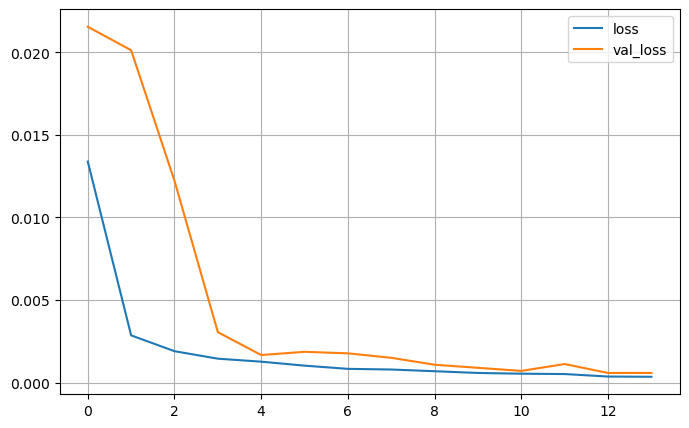

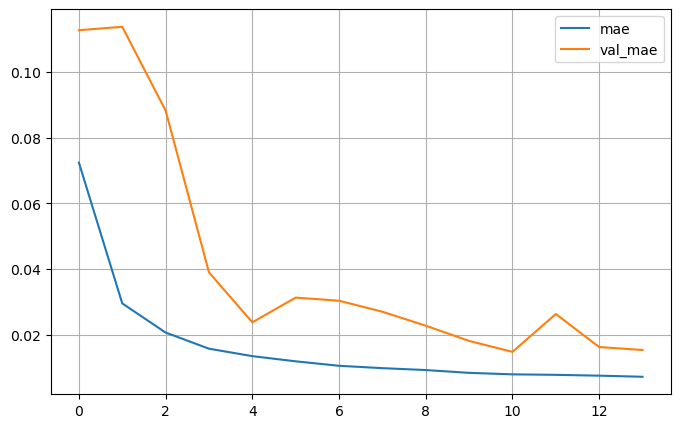

In [37]:
pd.DataFrame(history.history)[['loss', 'val_loss']].plot(figsize=(8, 5))
plt.grid(True)
plt.show()

pd.DataFrame(history.history)[['mae', 'val_mae']].plot(figsize=(8, 5))
plt.grid(True)
plt.show() 